## Table of Contents:
* [1. Load Input Files](#first-bullet)
* [2. Initial Data Visualizaton](#second-bullet)
* [3. Are PWM metrics correlated w/Number of Footprints?](#third-bullet)

In [23]:
import pybedtools, os, re, itertools
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
import scipy.stats as stats

# 1. Load Input Files

In [24]:
def _quickformat(tool, intype):
    all_cols = ["HEPG2", "MCF7", "K562", "GM12878", "SKNSH"]
    
    df1 = pd.read_table(f"01_inputfiles/01_{intype}_results_PWM.csv.gz", sep=",")
    df1 = pd.melt(
            df1,
            id_vars=[i for i in df1.columns if i not in all_cols],
            value_vars=all_cols,
            var_name="cell_line",
            value_name="peak_prevalence"
    )
    
    df2 = pd.read_table(f"01_inputfiles/01_{intype}_results_{tool}.csv.gz", sep=",")
    df2 = pd.melt(
            df2,
            id_vars=[i for i in df2.columns if i not in all_cols],
            value_vars=all_cols,
            var_name="cell_line",
            value_name="NoFootprints"
    )
    
    
    df = df2.merge(df1[["motif", "cell_line", "peak_prevalence"]], on=["motif", "cell_line"], how='outer')
    df["tool"] = tool
    df["type"] = intype
    return df


joint_df = pd.concat([_quickformat("HINT", "simulated"),
                      _quickformat("TOBIAS", "simulated"),
                      _quickformat("PRINT", "simulated"),
                      _quickformat("HINT", "jaspar"),
                      _quickformat("TOBIAS", "jaspar"),
                      _quickformat("PRINT", "jaspar")], axis=0)
                
joint_df["relative_value"] = (joint_df["NoFootprints"]/joint_df["peak_prevalence"])*100
display(joint_df)
#dataframe of just tools w/ values relative to motif scanning.  

,TF,IC,len,GC_content,Repeat_content,chr10_prevalence,motif,cell_line,NoFootprints,peak_prevalence,tool,type,obs,USF,HEPG2_expression,GM12878_expression,K562_expression,merge_on,relative_value
0,FAKE_ALL_100,23.403398,22,0.447950,0.310389,20145.0,FAKE_ALL_100_FAKE_ALL_100,GM12878,9788.0,35884.0,HINT,simulated,NaN,NaN,NaN,NaN,NaN,NaN,27.276781
1,FAKE_ALL_100,23.403398,22,0.447950,0.310389,20145.0,FAKE_ALL_100_FAKE_ALL_100,HEPG2,7370.0,30228.0,HINT,simulated,NaN,NaN,NaN,NaN,NaN,NaN,24.381368
2,FAKE_ALL_100,23.403398,22,0.447950,0.310389,20145.0,FAKE_ALL_100_FAKE_ALL_100,K562,9830.0,41194.0,HINT,simulated,NaN,NaN,NaN,NaN,NaN,NaN,23.862698
3,FAKE_ALL_100,23.403398,22,0.447950,0.310389,20145.0,FAKE_ALL_100_FAKE_ALL_100,MCF7,5343.0,23417.0,HINT,simulated,NaN,NaN,NaN,NaN,NaN,NaN,22.816757
4,FAKE_ALL_100,23.403398,22,0.447950,0.310389,20145.0,FAKE_ALL_100_FAKE_ALL_100,SKNSH,7772.0,30796.0,HINT,simulated,NaN,NaN,NaN,NaN,NaN,NaN,25.237044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4200,ZSCAN4,21.078791,15,0.476427,0.384991,22168.0,ZSCAN4_MA1155.1,GM12878,9588.0,40514.0,PRINT,jaspar,2125.0,0.0,0.419,0.02,0.001875,ZSCAN4_MA1155.1,23.665893
4201,ZSCAN4,21.078791,15,0.476427,0.384991,22168.0,ZSCAN4_MA1155.1,HEPG2,8747.0,34510.0,PRINT,jaspar,2125.0,0.0,0.419,0.02,0.001875,ZSCAN4_MA1155.1,25.346276
4202,ZSCAN4,21.078791,15,0.476427,0.384991,22168.0,ZSCAN4_MA1155.1,K562,8571.0,39015.0,PRINT,jaspar,2125.0,0.0,0.419,0.02,0.001875,ZSCAN4_MA1155.1,21.968474
4203,ZSCAN4,21.078791,15,0.476427,0.384991,22168.0,ZSCAN4_MA1155.1,MCF7,9652.0,30211.0,PRINT,jaspar,2125.0,0.0,0.419,0.02,0.001875,ZSCAN4_MA1155.1,31.948628


In [25]:
def _quickformat2(tool, intype):
    all_cols = ["HEPG2", "MCF7", "K562", "GM12878", "SKNSH"]
    
    df = pd.read_table(f"01_inputfiles/01_{intype}_results_{tool}.csv.gz", sep=",")
    df = pd.melt(
            df,
            id_vars=[i for i in df.columns if i not in all_cols],
            value_vars=all_cols,
            var_name="cell_line",
            value_name="value"
    )
    df["tool"] = tool
    df["type"] = intype
    return df


joint_df_long = pd.concat([_quickformat2("PWM", "simulated"), 
                           _quickformat2("HINT", "simulated"), 
                           _quickformat2("TOBIAS", "simulated"), 
                           _quickformat2("PRINT", "simulated"), 
                           _quickformat2("PWM", "jaspar"), 
                           _quickformat2("HINT", "jaspar"), 
                           _quickformat2("TOBIAS", "jaspar"),
                           _quickformat2("PRINT", "jaspar")
                          ], axis=0)
display(joint_df_long)
#dataframe including PWM results 

,TF,IC,len,GC_content,Repeat_content,chr10_prevalence,motif,cell_line,value,tool,type,obs,USF,HEPG2_expression,GM12878_expression,K562_expression,merge_on
0,FAKE_ALL_1,9.669563,6,0.676648,0.516852,324485.0,FAKE_ALL_1_FAKE_ALL_1,HEPG2,727242.0,PWM,simulated,NaN,NaN,NaN,NaN,NaN,NaN
1,FAKE_ALL_10,7.677256,7,0.320848,0.401730,892646.0,FAKE_ALL_10_FAKE_ALL_10,HEPG2,1101270.0,PWM,simulated,NaN,NaN,NaN,NaN,NaN,NaN
2,FAKE_ALL_100,23.403398,22,0.447950,0.310389,20145.0,FAKE_ALL_100_FAKE_ALL_100,HEPG2,30228.0,PWM,simulated,NaN,NaN,NaN,NaN,NaN,NaN
3,FAKE_ALL_101,24.889408,22,0.601676,0.337863,1501.0,FAKE_ALL_101_FAKE_ALL_101,HEPG2,4700.0,PWM,simulated,NaN,NaN,NaN,NaN,NaN,NaN
4,FAKE_ALL_102,22.341883,22,0.415137,0.332184,7194.0,FAKE_ALL_102_FAKE_ALL_102,HEPG2,9767.0,PWM,simulated,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4200,ZNF85,15.359574,16,0.419310,0.338706,192254.0,ZNF85_MA1720.1,SKNSH,5631.0,PRINT,jaspar,584.0,0.0,1.4695,10.7035,0.653125,ZNF85_MA1720.1
4201,ZNF93,16.175846,16,0.745678,0.468049,72871.0,ZNF93_MA1721.1,SKNSH,14844.0,PRINT,jaspar,2388.0,0.0,0.3450,3.0070,7.427187,ZNF93_MA1721.1
4202,ZSCAN29,14.774329,12,0.568034,0.325625,32204.0,ZSCAN29_MA1602.1,SKNSH,1522.0,PRINT,jaspar,999.0,0.0,10.1180,7.5915,8.703125,ZSCAN29_MA1602.1
4203,ZSCAN31,24.794394,19,0.571115,0.365572,2668.0,ZSCAN31_MA1722.1,SKNSH,3216.0,PRINT,jaspar,8838.0,0.0,4.0575,1.5900,4.339062,ZSCAN31_MA1722.1


# 2. Initial Data Visualization

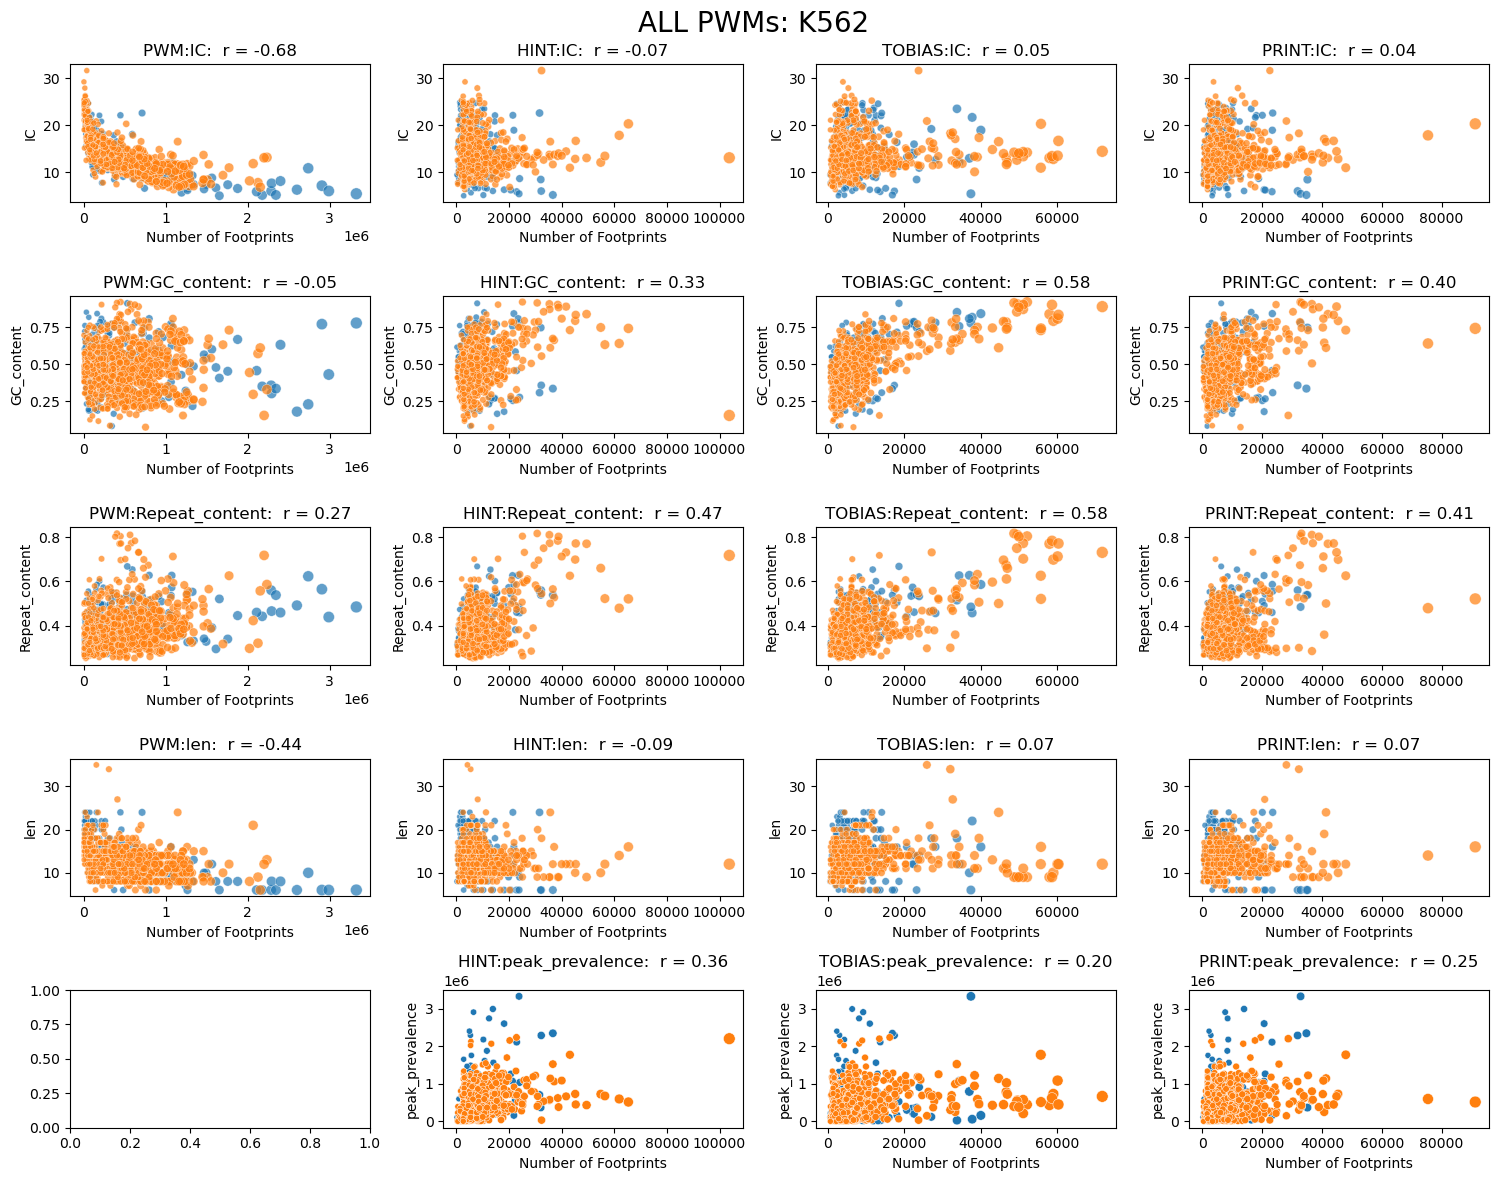

In [26]:
### HOW DO THE NUMBER OF FOOTPRINTS RELATE TO METRICS?

fig, axes = plt.subplots(5, 4, figsize=(15,12))
axes = axes.flatten()

tools = ["PWM", "HINT", "TOBIAS", "PRINT"]
metrics = ["IC", "GC_content", "Repeat_content", "len"]
types = ["jaspar", "simulated"]
cl = "K562"
xval = "value"

for ax, t, m in zip(axes, 
                     tools * len(metrics), 
                     [i for i in metrics for _ in tools]):
    subset = joint_df_long[(joint_df_long["tool"] == t) & 
                           (joint_df_long["cell_line"] == cl) &
                           (joint_df_long["type"].isin(types))]
        
    sns.scatterplot(data=subset, x=xval, y=m, 
                    size=xval, hue="type", 
                    ax=ax, s=30, legend=False, alpha=0.7)
    corr_coef, p_value = stats.pearsonr(x=np.array(subset[xval]), y=np.array(subset[m]))
    ax.set_title(f'{t}:{m}:  r = {corr_coef:.2f}', fontsize=12)
    ax.set_xlabel("Number of Footprints")

for ax, t in zip(axes[17:20], ["HINT", "TOBIAS", "PRINT"]):
    subset = joint_df[(joint_df["tool"] == t) & 
                      (joint_df["cell_line"] == cl) &
                      (joint_df["type"].isin(types))]
    sns.scatterplot(data=subset, x='NoFootprints', y='peak_prevalence',
                    size="NoFootprints", hue="type", 
                    ax=ax, s=30, legend=False)
    corr_coef, p_value = stats.pearsonr(x=np.array(subset["NoFootprints"]), y=np.array(subset["peak_prevalence"]))
    ax.set_title(f'{t}:peak_prevalence:  r = {corr_coef:.2f}', fontsize=12)
    ax.set_xlabel("Number of Footprints")
    
fig.suptitle('ALL PWMs: K562', fontsize=20)

plt.tight_layout()
plt.show()

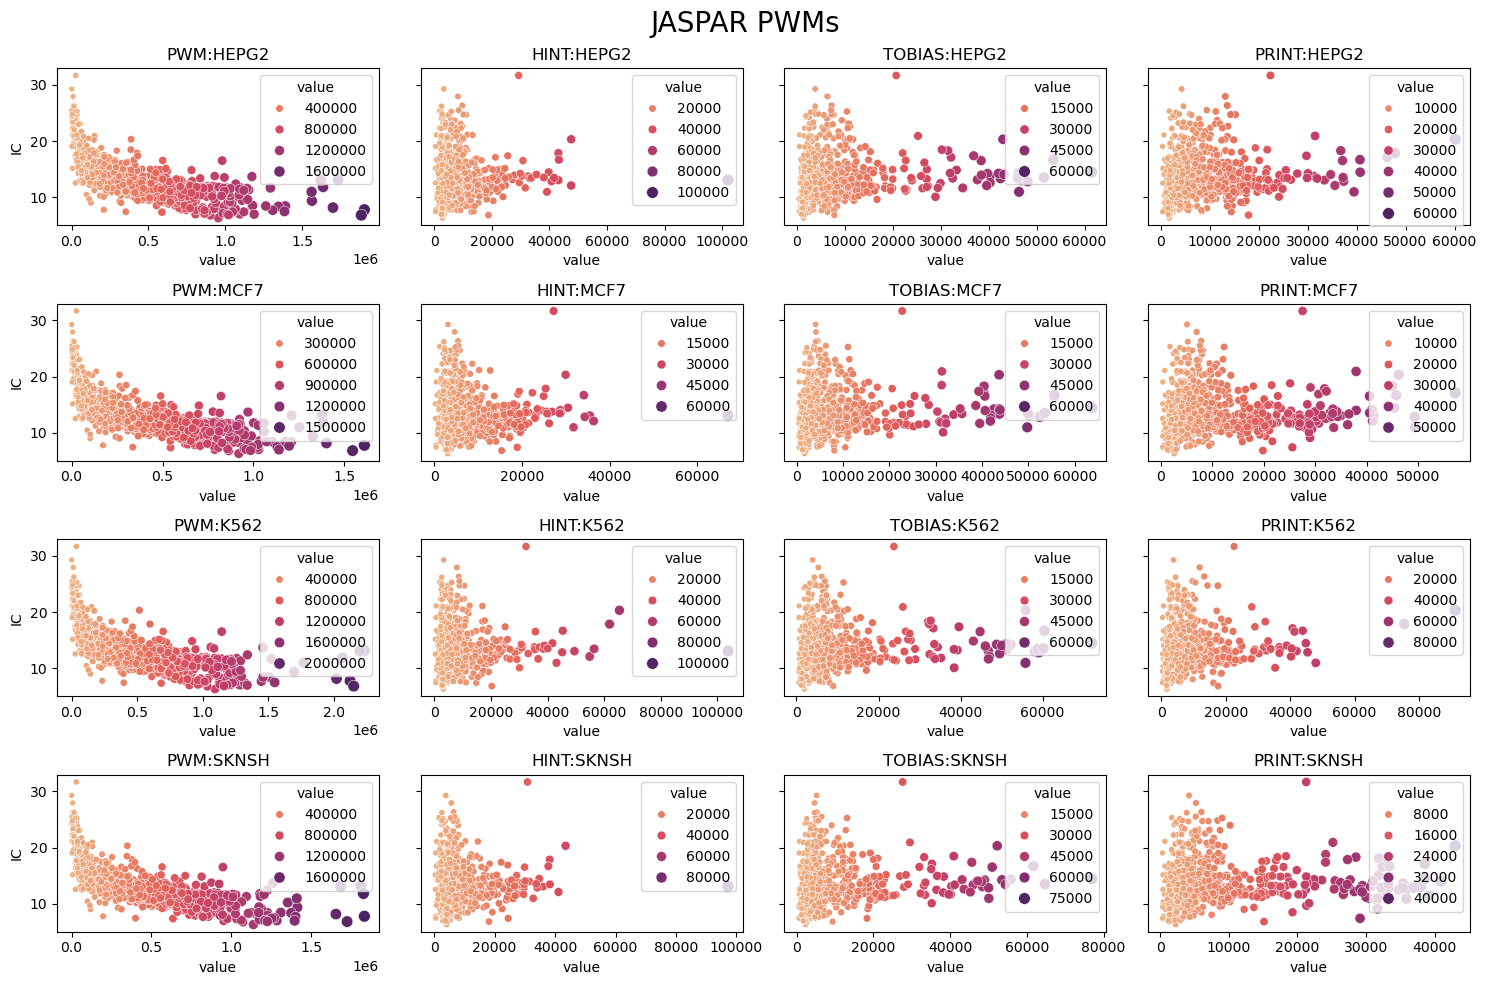

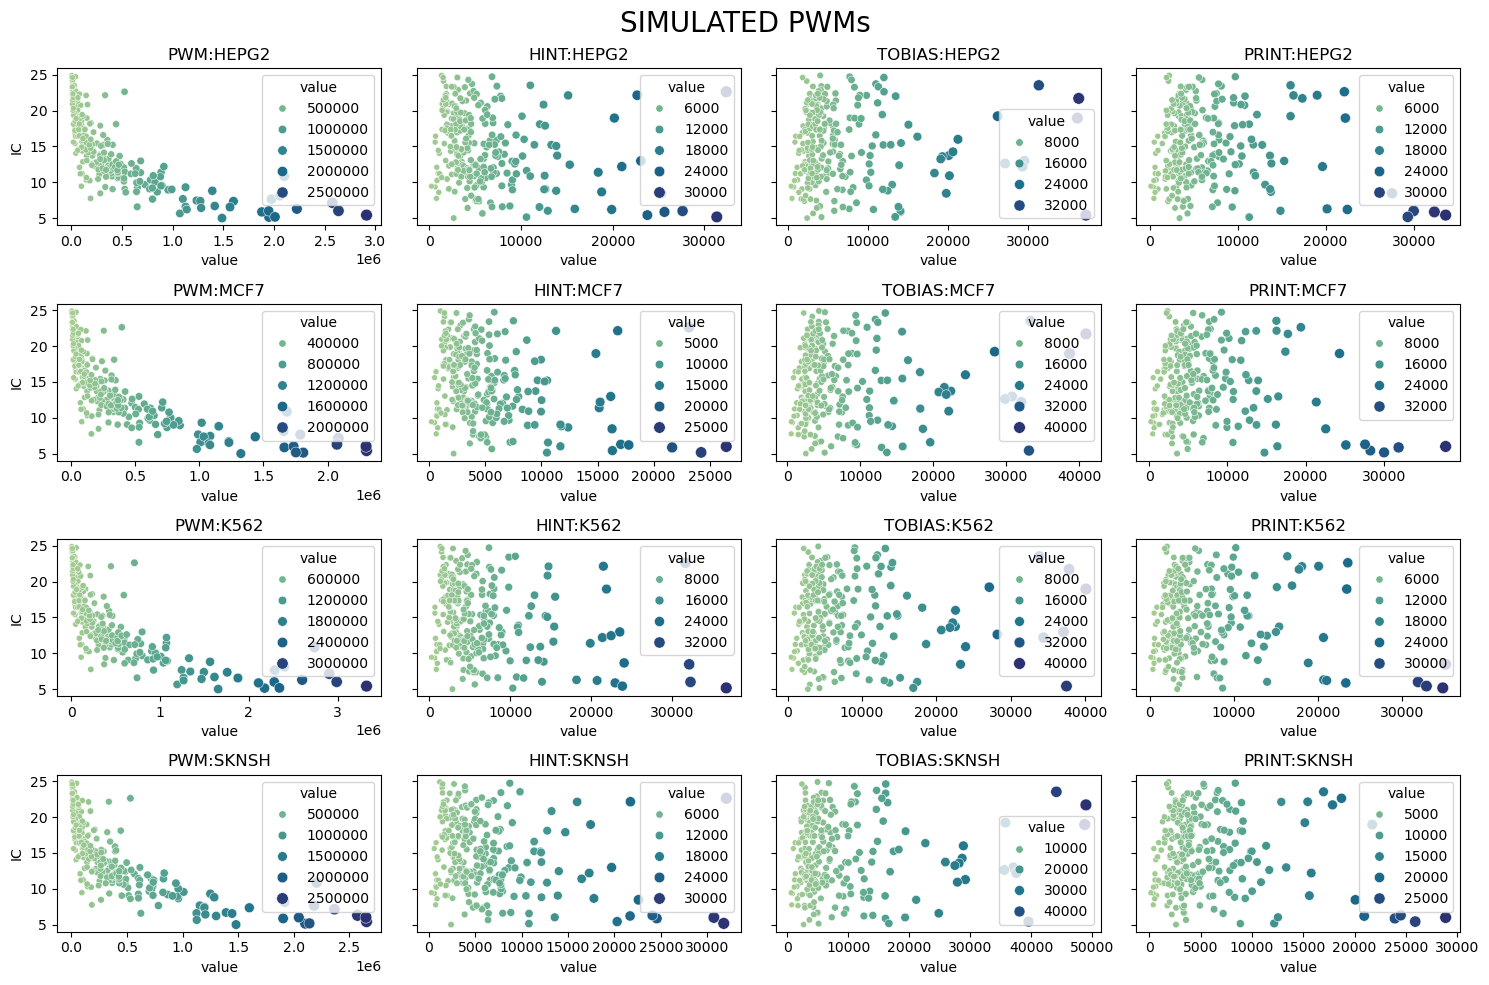

In [27]:
#### IS THIS SHARED ACROSS CELL LINES? 

def _PlotbyCellLine(toplot = "jaspar", xval="IC", yval = "IC", pal="flare", title=""):
    fig, axes = plt.subplots(4, 4, figsize=(15,10), sharey=True)
    axes = axes.flatten()

    tools = ["PWM", "HINT", "TOBIAS", "PRINT"]
    celllines = ["HEPG2", "MCF7", "K562", "SKNSH"] #GM12878
    
    for ax, t, cl in zip(axes, 
                         tools * len(celllines), 
                         [i for i in celllines for _ in tools]):

        subset = joint_df_long[(joint_df_long["tool"] == t) & 
                               (joint_df_long["cell_line"] == cl) & 
                               (joint_df_long["type"] == toplot)]
        sns.scatterplot(data=subset, x=xval, y=yval, 
                        size=xval, hue=xval, palette=pal,
                        ax=ax, s=30)
        ax.set_title(f"{t}:{cl}")
        ax.set_xlabel(xval)

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()
    return

_PlotbyCellLine(toplot = "jaspar", xval="value", yval="IC", pal="flare", title='JASPAR PWMs')

_PlotbyCellLine(toplot = "simulated", xval="value", yval="IC", pal="crest", title='SIMULATED PWMs')

# 3. Correlation of PWM metrics & number of footprints

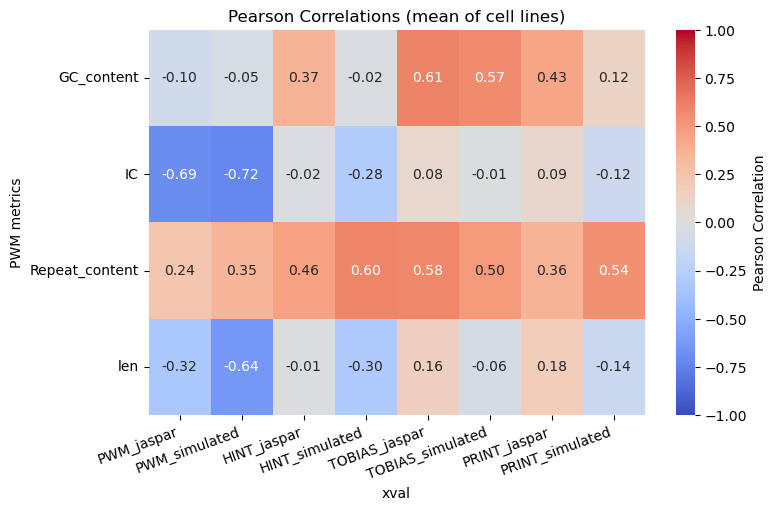

In [28]:
tools = ["PWM", "TOBIAS", "HINT", "PRINT"]
metrics = ["IC", "GC_content", "Repeat_content", "len"]
cellines = ['HEPG2', 'K562', 'MCF7', 'SKNSH']
pwm_type = ["jaspar","simulated"]
combinations = list(itertools.product(tools, metrics, cellines, pwm_type))

results=list()
for t,m,c,pt in combinations:
    subset = joint_df_long[(joint_df_long["tool"] == t) & 
                           (joint_df_long["cell_line"] == c) &
                           (joint_df_long["type"] == pt)]
    
    corr_coef, p_value = stats.pearsonr(x=np.array(subset["value"]), y=np.array(subset[m]))
    results.append([t, m, c, pt, corr_coef])

correlation_df = pd.DataFrame(results, columns = ['tool', 'metric', 'cellline', 'pwm_type', 'pearsonr']) 
correlation_df["category"] = correlation_df.metric + "_" + correlation_df.pwm_type + "_" + correlation_df.cellline

tmp = pd.DataFrame({'pearsonr_mean' : correlation_df.groupby(["tool", "metric", "pwm_type"])['pearsonr'].mean()}).reset_index()
tmp["xval"] = tmp["tool"] + "_" + tmp["pwm_type"]

heat_df= tmp.pivot(index='metric', columns='xval', values='pearsonr_mean')
plt.figure(figsize=(8, 5))
sns.heatmap(heat_df[["PWM_jaspar", "PWM_simulated", 
                     "HINT_jaspar", "HINT_simulated", 
                     "TOBIAS_jaspar","TOBIAS_simulated",
                     "PRINT_jaspar","PRINT_simulated"]], 
            annot=True, 
            fmt=".2f", 
            vmin=-1, vmax=1,cmap="coolwarm", 
            cbar_kws={"label": "Pearson Correlation"})
plt.title("Pearson Correlations (mean of cell lines)")
plt.ylabel("PWM metrics")
plt.xticks(rotation=20, ha='right') 
plt.yticks(rotation=0) 
plt.show()

# 4. Tools rank jaspar PWMs nearly identical, do simulated PWMs do the same?

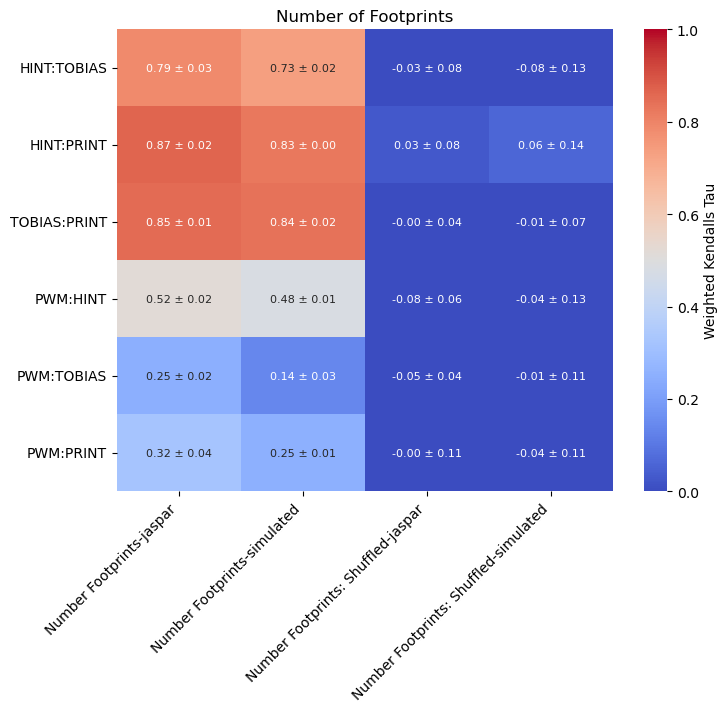

In [29]:
def _KT_AcrossTools(df, 
                    cell_lines = ["HEPG2", "MCF7", "K562", "SKNSH"], 
                    tools = ["PWM", "HINT","TOBIAS", "PRINT"], 
                    pwm_type = ["jaspar","simulated"],
                    rankby="#footprints"):
    
    from scipy.stats import kendalltau, weightedtau

    results=list()
    for cl, pt in zip(cell_lines*2, [i for i in pwm_type for _ in cell_lines]): #pwm_type * 4):
        for t1, t2 in list(itertools.combinations(tools, 2)):

            cond1 = (df["cell_line"] == cl)
            cond2 = (df["type"] == pt)
            sorted_motifs_list1=df.loc[(df.tool==t1) & cond1 & cond2].sort_values(by=rankby, ascending=False)["motif"]
            sorted_motifs_list2=df.loc[(df.tool==t2) & cond1 & cond2].sort_values(by=rankby, ascending=False)["motif"]

            rank_map = {char: rank for rank, char in enumerate(sorted_motifs_list1)}
            ranked_motifs_list1 = [rank_map[char] for char in sorted_motifs_list1]
            ranked_motifs_list2 = [rank_map[char] for char in sorted_motifs_list2]

            kt_cor, pval = kendalltau(ranked_motifs_list1, ranked_motifs_list2) #identical to weightedtau(ranked_list1, ranked_list2, weigher=lambda x: 1)
            wkt_cor = weightedtau(ranked_motifs_list1, ranked_motifs_list2)
            results.append([cl, pt, t1, t2, kt_cor, wkt_cor.statistic])

    tau_df = pd.DataFrame(results, columns = ['CellLine','pwm_type', 'tool1', 'tool2', 'kendall_tau', 'kendall_tau_weighted']) 
    tau_df["tools"] = tau_df["tool1"] + ":" + tau_df["tool2"]
    return tau_df

    

joint_df_long["#footprints"] = joint_df_long["value"]
joint_df_long['#footprints_shuffled'] = (
    joint_df_long.groupby(["tool", "cell_line", "type"])['#footprints']
      .transform(lambda x: np.random.permutation(x.values))
)


tmp1 = _KT_AcrossTools(joint_df_long, rankby="#footprints")
tmp1["comparison"] = "Number Footprints"

tmp2 = _KT_AcrossTools(joint_df_long, rankby="#footprints_shuffled")
tmp2["comparison"] = "Number Footprints: Shuffled"

tau_df = pd.concat([tmp1, tmp2])
tau_df["comparison"] = tau_df["comparison"] + "-" + tau_df["pwm_type"]
tau_df_grouped = pd.DataFrame({'mean' : tau_df.groupby(["tools", "comparison", "pwm_type"])['kendall_tau_weighted'].mean(),
                               'sd'   : tau_df.groupby(["tools", "comparison", "pwm_type"])['kendall_tau_weighted'].std()}).reset_index()
tau_df_grouped["labels"] = tau_df_grouped.apply(lambda row: f"{row['mean']:.2f} ± {row['sd']:.2f}", axis=1)

#display(tau_df_grouped)


toplot = tau_df_grouped.pivot(index='tools', columns='comparison', values='mean')
labels = tau_df_grouped.pivot(index='tools', columns='comparison', values='labels')
ylabel_order = ["HINT:TOBIAS", "HINT:PRINT", "TOBIAS:PRINT", "PWM:HINT", "PWM:TOBIAS", "PWM:PRINT"]

plt.figure(figsize=(8, 6))
sns.heatmap(toplot.loc[ylabel_order],
            annot = labels.loc[ylabel_order],  
            fmt = '', annot_kws={"size": 8},
            vmin=0, vmax=1,
            cmap="coolwarm", cbar_kws={"label": "Weighted Kendalls Tau"})
plt.ylabel(""); plt.xlabel("")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0) 
plt.title("Number of Footprints")
plt.show()

- yes

# 5. Could a simple model predict the number of footprints well based on PWM features?

In [30]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results=list()
coef = list()
joint_df["residual"] = np.nan

for cl in ["HEPG2", "MCF7", "K562", "GM12878", "SKNSH"]:
    df_sim  = joint_df[(joint_df["cell_line"] == cl) & (joint_df["type"] == "simulated")].copy()
    df_real = joint_df[(joint_df["cell_line"] == cl) & (joint_df["type"] == "jaspar")].copy()

    #1. Split data
    train_sim, test_sim = train_test_split(df_sim.TF, test_size=0.3, random_state=42)
    train_real, test_real = train_test_split(df_real.TF, test_size=0.3, random_state=42)

    for t in ["TOBIAS","HINT",  "PRINT"]:
        train_sim_df = df_sim[(df_sim.tool == t) & (df_sim.TF.isin(train_sim))]
        train_real_df = df_real[(df_real.tool == t) & (df_real.TF.isin(train_real))]

        test_sim_df = df_sim[(df_sim.tool == t) & (df_sim.TF.isin(test_sim))]
        test_real_df = df_real[(df_real.tool == t) & (df_real.TF.isin(test_real))]

        # 2. Fit models
        #our_formula = 'relative_value ~ peak_prevalence * GC_content * IC * Repeat_content'
        our_formula = 'relative_value ~ GC_content * IC * Repeat_content'
        model_sim = smf.ols(formula=our_formula, data=train_sim_df).fit()
        model_real = smf.ols(formula=our_formula, data=train_real_df).fit()
        
        # 3. Predict on test data
        sim_pred_sim = model_sim.predict(test_sim_df)
        real_pred_real = model_real.predict(test_real_df)
        sim_pred_real = model_sim.predict(test_real_df)
        real_pred_sim = model_real.predict(test_sim_df)

        #4. Output results. 
        r2_info = {
            "Cell Line": cl,
            "Tool": t,
            "R2_simulated": r2_score(test_sim_df['relative_value'], sim_pred_sim),
            "MSE_simulated": mean_squared_error(test_sim_df['relative_value'], sim_pred_sim),
            
            "R2_jaspar": r2_score(test_real_df['relative_value'], real_pred_real),
            "MSE_jaspar": mean_squared_error(test_real_df['relative_value'], real_pred_real),
        
            "R2_sim_on_real": r2_score(test_real_df['relative_value'], sim_pred_real),
            "MSE_sim_on_real": mean_squared_error(test_real_df['relative_value'], sim_pred_real),
        
            "R2_real_on_sim": r2_score(test_sim_df['relative_value'], real_pred_sim),
            "MSE_real_on_sim": mean_squared_error(test_sim_df['relative_value'], real_pred_sim),
        }
        results.append(r2_info)

        coef_info = pd.DataFrame({
            "Cell Line": cl,
            "Tool": t,
            'term': model_sim.params.index,
            'coef_sim': model_sim.params.values,
            'coef_real': model_real.params.reindex(model_sim.params.index).values
        })
        coef.append(coef_info)

        cond1 = (joint_df.tool == t)
        cond2 = (joint_df.cell_line == cl)
        joint_df.loc[cond1 & cond2, "residual"] =  joint_df.loc[cond1 & cond2, "relative_value"] -  model_sim.predict(joint_df.loc[cond1 & cond2])
            
print("done")

done


In [31]:
result_df = pd.DataFrame(results)

val_columns = ['R2_simulated', 'R2_jaspar', 'R2_sim_on_real']
grouped_mean = result_df.groupby("Tool")[val_columns].mean().add_suffix("_mean")
grouped_sd = result_df.groupby("Tool")[val_columns].std().add_suffix("_sd")
mean_sd_df = grouped_mean.merge(grouped_sd, left_index=True, right_index=True).reset_index()

clean_df = pd.DataFrame()
clean_df["Tool"] = mean_sd_df["Tool"]

# Loop through each metric prefix (e.g., R2_simulated)
for col in val_columns:
    mean_col = f"{col}_mean"
    sd_col = f"{col}_sd"
    
    clean_df[col] = mean_sd_df.apply(
        lambda row: f"{row[mean_col]:.2f} ± {row[sd_col]:.2f}", axis=1
    )
display(clean_df)  
clean_df.columns = ["Tool", "R2 on Simulated PWMs on Simulated PWMs", "R-squared JASPAR PWM model", "R-squared simulation"]

,Tool,R2_simulated,R2_jaspar,R2_sim_on_real
0,HINT,0.69 ± 0.00,0.39 ± 0.01,0.26 ± 0.01
1,PRINT,0.70 ± 0.01,0.40 ± 0.03,0.35 ± 0.01
2,TOBIAS,0.68 ± 0.02,0.03 ± 0.11,0.29 ± 0.06


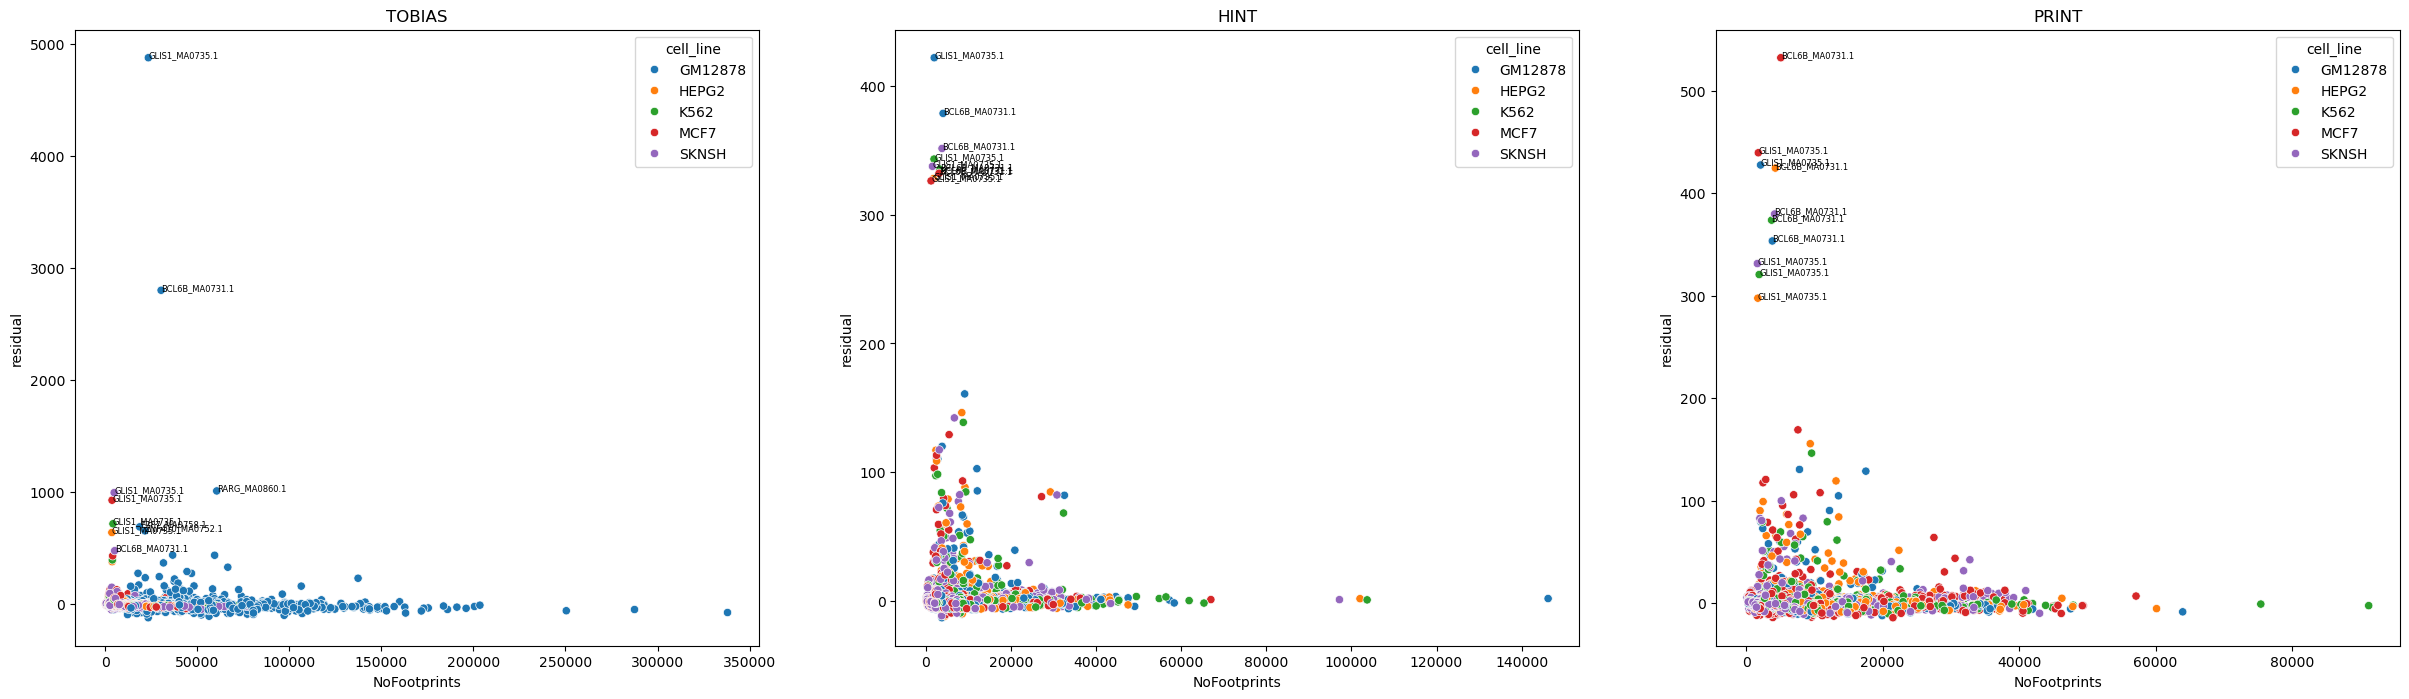

In [32]:
fig = plt.figure(figsize=(30, 8))
gs = GridSpec(1, 3, figure=fig)#, width_ratios=[1,2])

ax0 = fig.add_subplot(gs[0])  
t = "TOBIAS"
ax0 = sns.scatterplot(data=joint_df[joint_df.tool == t], x="NoFootprints", y="residual", hue="cell_line")
ax0.set_title(t)
ax.set_ylim(0, 500)
tmp = joint_df[joint_df.tool == t].sort_values("residual", ascending=False)
for i, row in tmp[0:10].iterrows():
    ax0.text(x=row["NoFootprints"], y=row['residual'], s=row['motif'], size=6)

ax0 = fig.add_subplot(gs[1])  
t = "HINT"
ax0 = sns.scatterplot(data=joint_df[joint_df.tool == t], x="NoFootprints", y="residual", hue="cell_line")
ax0.set_title(t)
ax.set_ylim(0, 500)
tmp = joint_df[joint_df.tool == t].sort_values("residual", ascending=False)
for i, row in tmp[0:10].iterrows():
    ax0.text(x=row["NoFootprints"], y=row['residual'], s=row['motif'], size=6)


ax0 = fig.add_subplot(gs[2])  
t = "PRINT"
ax0 = sns.scatterplot(data=joint_df[joint_df.tool == t], x="NoFootprints", y="residual", hue="cell_line")
ax0.set_title(t)
ax.set_ylim(0, 500)
tmp = joint_df[joint_df.tool == t].sort_values("residual", ascending=False)
for i, row in tmp[0:10].iterrows():
    ax0.text(x=row["NoFootprints"], y=row['residual'], s=row['motif'], size=6)

plt.show()


- supports TOBIAS being particularly poor at GM12878
- Interesting that GLIS1 and BCL6B consistently have the highest residuals across CLs and tools? 